B"H

## Project 3: Adult Census Income

- David Koyrakh
- Bellevue University
- DSC-680: Applied Data Science
- Professor Iranitalab


This notebook includes data preparation, modeling, and evaluation to support the Project 3 study on the Adult Census Income dataset.

### Load dataset

I begin by loading the Adult Census Income dataset and setting up a consistent analysis environment. This step confirms file access, records the dataset shape, inspects data types, and previews a few rows.

In [13]:
# Imports and environment setup
import os
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns

# Reproducibility and plot style
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# Load data
DATA_PATH = os.path.join("data", "adult.csv")
df = pd.read_csv(DATA_PATH)

# Quick schema snapshot and preview
print("Rows, Columns:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes.to_string())
print("\nIncome value counts:")
print(df["income"].value_counts(dropna=False).to_string())
print("\nHead (first 5 rows):")
print(df.head(5).to_string(index=False))

Rows, Columns: (32561, 15)

Column dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object

Income value counts:
income
<=50K    24720
>50K      7841

Head (first 5 rows):
 age workclass  fnlwgt    education  education.num marital.status        occupation  relationship  race    sex  capital.gain  capital.loss  hours.per.week native.country income
  90         ?   77053      HS-grad              9        Widowed                 ? Not-in-family White Female             0          4356              40  United-States  <=50K
  82   Private  132870      HS-grad              9        Widowed   Exec-managerial Not-in-family White Female             0          4356         

- The dataset contains 32,561 rows and 15 columns.
- The target `income` is imbalanced with more `<=50K` than `>50K`.
- Features include both numeric (e.g., `age`, `hours.per.week`, `capital.gain/loss`) and categorical fields (e.g., `workclass`, `education`, `marital.status`).
- A literal `?` appears in several categorical fields, indicating missingness encoded as a string; I will map these to an explicit `Unknown` category during cleaning.
- Column names use periods and dashes; I will standardize to snake_case for consistency in downstream pipelines.

### Clean data, standardize columns, and encode target

In this step, I will:
- Standardize column names to snake_case.
- Trim whitespace and map literal `?` to `Unknown` in categorical columns.
- Create a binary target indicator for `income > 50K` for later models.
I will verify changes by printing class distribution, checking for remaining `?`, and previewing the cleaned frame.

In [14]:
# Standardize column names to snake_case for consistency
import re

def to_snake(name: str) -> str:
    name = name.strip().lower()
    name = name.replace(".", "_").replace("-", "_").replace("/", "_")
    name = re.sub(r"\s+", "_", name)
    name = re.sub(r"__+", "_", name)
    return name

original_to_new = {c: to_snake(c) for c in df.columns}
df.rename(columns=original_to_new, inplace=True)

# Identify categorical columns (object dtype) and clean values
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
for c in cat_cols:
    # strip whitespace and replace literal '?' with 'Unknown'
    df[c] = df[c].astype(str).str.strip().replace({'?': 'Unknown'})

# Create binary target: 1 if >50K else 0
if 'income' in df.columns:
    df['income_binary'] = (df['income'] == '>50K').astype(int)

# Quick verifications and summaries
num_rows, num_cols = df.shape
num_unknown_after = sum((df[c] == 'Unknown').sum() for c in cat_cols)
class_counts = df['income'].value_counts(dropna=False).to_dict() if 'income' in df.columns else {}

print("Shape after cleaning:", (num_rows, num_cols))
print("Unknown markers across categoricals (post-clean):", num_unknown_after)
print("Income class distribution:", class_counts)
# Confirm no literal '?' remains
any_q = any((df[c] == '?').any() for c in cat_cols)
print("Any '?' remaining in categoricals?", any_q)

print("\nHead of cleaned data:")
print(df.head(5).to_string(index=False))

Shape after cleaning: (32561, 16)
Unknown markers across categoricals (post-clean): 4262
Income class distribution: {'<=50K': 24720, '>50K': 7841}
Any '?' remaining in categoricals? False

Head of cleaned data:
 age workclass  fnlwgt    education  education_num marital_status        occupation  relationship  race    sex  capital_gain  capital_loss  hours_per_week native_country income  income_binary
  90   Unknown   77053      HS-grad              9        Widowed           Unknown Not-in-family White Female             0          4356              40  United-States  <=50K              0
  82   Private  132870      HS-grad              9        Widowed   Exec-managerial Not-in-family White Female             0          4356              18  United-States  <=50K              0
  66   Unknown  186061 Some-college             10        Widowed           Unknown     Unmarried Black Female             0          4356              40  United-States  <=50K              0
  54   Private  14035

- Columns standardized to snake_case; target encoded as `income_binary`.
- `Unknown` markers introduced for prior `?` values across categoricals: 4,262.
- Income class distribution unchanged: `{'<=50K': 24720, '>50K': 7841}`.
- No remaining literal `?` values in categoricals.
- Cleaned shape is `(32561, 16)`; preview confirms transformations on representative rows.

### EDA visuals to understand distributions and class balance

Next, I'll create a compact set of visuals to understand class balance and the distributions of two key numeric features (`age`, `hours_per_week`) and one categorical feature (`education`):

Saved EDA figure to: figures\eda_overview.png


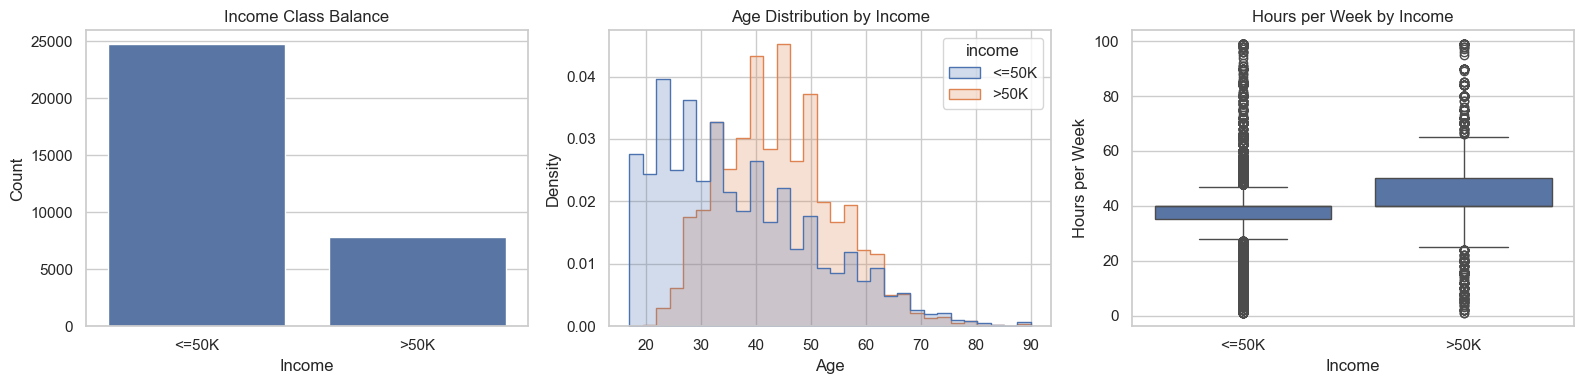


Top-10 education levels by count:
 education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576


In [ ]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure figures directory exists
FIG_DIR = os.path.join("figures")
os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Class balance
sns.countplot(x=df['income'], ax=axes[0], order=['<=50K', '>50K'])
axes[0].set_title('Income Class Balance')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')

# 2) Age distribution by income
sns.histplot(data=df, x='age', hue='income', bins=30, stat='density', common_norm=False, element='step', ax=axes[1])
axes[1].set_title('Age Distribution by Income')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')

# 3) Weekly hours by income (boxplot for compactness)
sns.boxplot(data=df, x='income', y='hours_per_week', order=['<=50K', '>50K'], ax=axes[2])
axes[2].set_title('Hours per Week by Income')
axes[2].set_xlabel('Income')
axes[2].set_ylabel('Hours per Week')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'eda_overview.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f"Saved EDA figure to: {fig_path}")
plt.show()

# Simple tabular snapshot for education levels (top 10)
edu_counts = df['education'].value_counts().head(10)
print("\nTop-10 education levels by count:\n", edu_counts.to_string())

### What was learned from the EDA

- Clear class imbalance: `<=50K` dominates `>50K`.
- `age` skews toward working-age with heavier right tail for `>50K`.
- `hours_per_week` shows higher central tendency/spread for `>50K`.
- These patterns support stratified splitting and encoding with care for skewed variables.

### Train/test split and preprocessing setup

Next, I'll create a stratified train/test split on the binary target and define preprocessing suitable for linear and tree models. Linear models benefit from scaled numerics with one-hot encoding; trees work well with one-hot on categoricals and raw numerics. I’ll preview the transformed feature counts to verify the pipeline.

In [16]:
# Split data and build preprocessing pipelines
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Feature/target split
assert 'income_binary' in df.columns, "Run cleaning cell to create income_binary"

# Drop original income label to avoid leakage
y = df['income_binary']
feature_cols = [c for c in df.columns if c not in ['income_binary', 'income']]
X = df[feature_cols]

# Identify columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train/Test shapes:", X_train.shape, X_test.shape)
print("Class balance (train):", y_train.value_counts(normalize=True).to_dict())
print("Class balance (test):", y_test.value_counts(normalize=True).to_dict())

# Preprocessor for Logistic Regression: scaled numerics + sparse one-hot cats
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(with_mean=True), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
    ],
    remainder='drop'
)

# Preprocessor for Random Forest: raw numerics + dense one-hot cats
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ],
    remainder='drop'
)

# Fit both preprocessors to preview transformed dimensionality
Xt_lr = preprocessor_lr.fit_transform(X_train, y_train)
Xt_rf = preprocessor_rf.fit_transform(X_train, y_train)

n_features_lr = Xt_lr.shape[1]
n_features_rf = Xt_rf.shape[1]
print(f"Transformed feature counts → LR: {n_features_lr}, RF: {n_features_rf}")

Train/Test shapes: (26048, 14) (6513, 14)
Class balance (train): {0: 0.7591753685503686, 1: 0.24082463144963145}
Class balance (test): {0: 0.7592507293106096, 1: 0.24074927068939045}
Transformed feature counts → LR: 107, RF: 107


### What I learned from split/preprocessing

- Stratified split preserves class balance: ~76% `<=50K`, ~24% `>50K` in both train and test.
- Train/test split: 26,048 / 6,513 rows.
- Both preprocessors yield 107 features after one-hot encoding (LR uses sparse, RF uses dense).
- Preprocessing pipelines are ready for model training.

### Train baseline Logistic Regression model

I start with Logistic Regression as an interpretable baseline. It provides coefficient-based feature importance and serves as a benchmark for more complex models. I use L2 regularization to prevent overfitting and train on the preprocessed features.

In [17]:
# Train Logistic Regression baseline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Build pipeline: preprocessor + model
pipe_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0))
])

# Train
print("Training Logistic Regression...")
pipe_lr.fit(X_train, y_train)

# Predictions
y_pred_lr = pipe_lr.predict(X_test)
y_pred_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

# Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nLogistic Regression Test Metrics:")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall:    {rec_lr:.4f}")
print(f"  F1-score:  {f1_lr:.4f}")
print(f"  ROC-AUC:   {roc_auc_lr:.4f}")
print(f"\nConfusion Matrix:")
print(cm_lr)

Training Logistic Regression...

Logistic Regression Test Metrics:
  Accuracy:  0.8543
  Precision: 0.7394
  Recall:    0.6097
  F1-score:  0.6683
  ROC-AUC:   0.9043

Confusion Matrix:
[[4608  337]
 [ 612  956]]


### What was learned from Logistic Regression

- Test Accuracy: 0.8543; Precision: 0.7394; Recall: 0.6097; F1: 0.6683; ROC-AUC: 0.9043.
- Confusion matrix shows more false negatives than false positives (612 vs 337), consistent with class imbalance and conservative thresholding.
- Solid baseline with strong AUC; recall leaves room for improvement (trees/threshold tuning may help).

### Train Random Forest benchmark

Random Forest provides a robust non-linear baseline that often improves recall on tabular data. Next I'll train with moderate complexity to keep execution fast and report the same metrics for apples-to-apples comparison.

In [18]:
# Train Random Forest benchmark
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Build pipeline: preprocessor + model
pipe_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

print("Training Random Forest...")
pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)
y_pred_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nRandom Forest Test Metrics:")
print(f"  Accuracy:  {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall:    {rec_rf:.4f}")
print(f"  F1-score:  {f1_rf:.4f}")
print(f"  ROC-AUC:   {roc_auc_rf:.4f}")
print(f"\nConfusion Matrix:\n{cm_rf}")

Training Random Forest...

Random Forest Test Metrics:
  Accuracy:  0.8532
  Precision: 0.7280
  Recall:    0.6231
  F1-score:  0.6715
  ROC-AUC:   0.9000

Confusion Matrix:
[[4580  365]
 [ 591  977]]


### What I learned from Random Forest

- Test Accuracy: 0.8532; Precision: 0.7280; Recall: 0.6231; F1: 0.6715; ROC-AUC: 0.9000.
- Recall is modestly higher than Logistic Regression with comparable accuracy/AUC, matching expectations for trees on tabular data.
- Error pattern remains asymmetric but slightly fewer false negatives than LR (591 vs 612).

### Plot ROC curves and confusion matrices

Next, I'm going to generate compact ROC curves for both models and side-by-side confusion matrices:

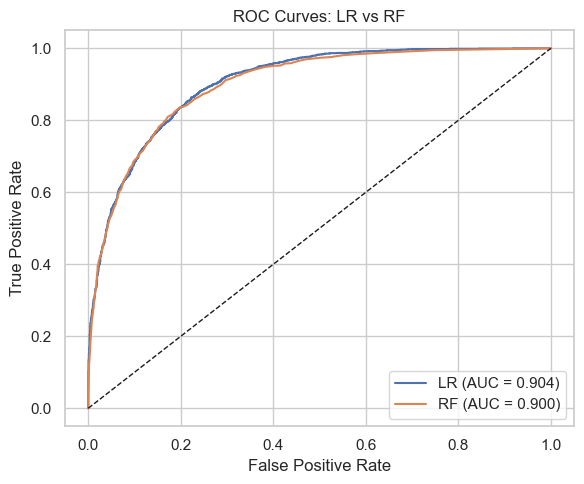

Saved ROC figure to: figures\roc_lr_rf.png


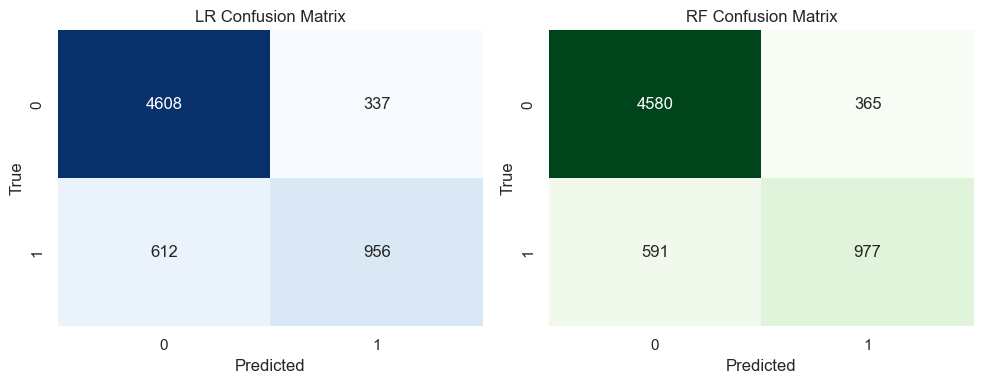

Saved confusion matrices to: figures\confusion_lr_rf.png


In [19]:
# ROC and confusion matrix plots for both models
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

os.makedirs("figures", exist_ok=True)

# Recompute predictions to ensure this cell is self-contained
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
pred_lr = pipe_lr.predict(X_test)
pred_rf = pipe_rf.predict(X_test)

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {roc_auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1],[0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: LR vs RF')
plt.legend(loc='lower right')
roc_path = os.path.join('figures', 'roc_lr_rf.png')
plt.tight_layout()
plt.savefig(roc_path, dpi=120)
plt.show()
print(f"Saved ROC figure to: {roc_path}")

# Confusion matrices
cm_lr = confusion_matrix(y_test, pred_lr)
cm_rf = confusion_matrix(y_test, pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('LR Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1])
axes[1].set_title('RF Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
cm_path = os.path.join('figures', 'confusion_lr_rf.png')
plt.savefig(cm_path, dpi=120)
plt.show()
print(f"Saved confusion matrices to: {cm_path}")

### Model interpretation: LR coefficients and RF importances

I extract interpretable signals from both models: top positive/negative Logistic Regression coefficients and top Random Forest feature importances. This reveals which attributes most increase/decrease the odds of `>50K` and which variables the RF relies on most.

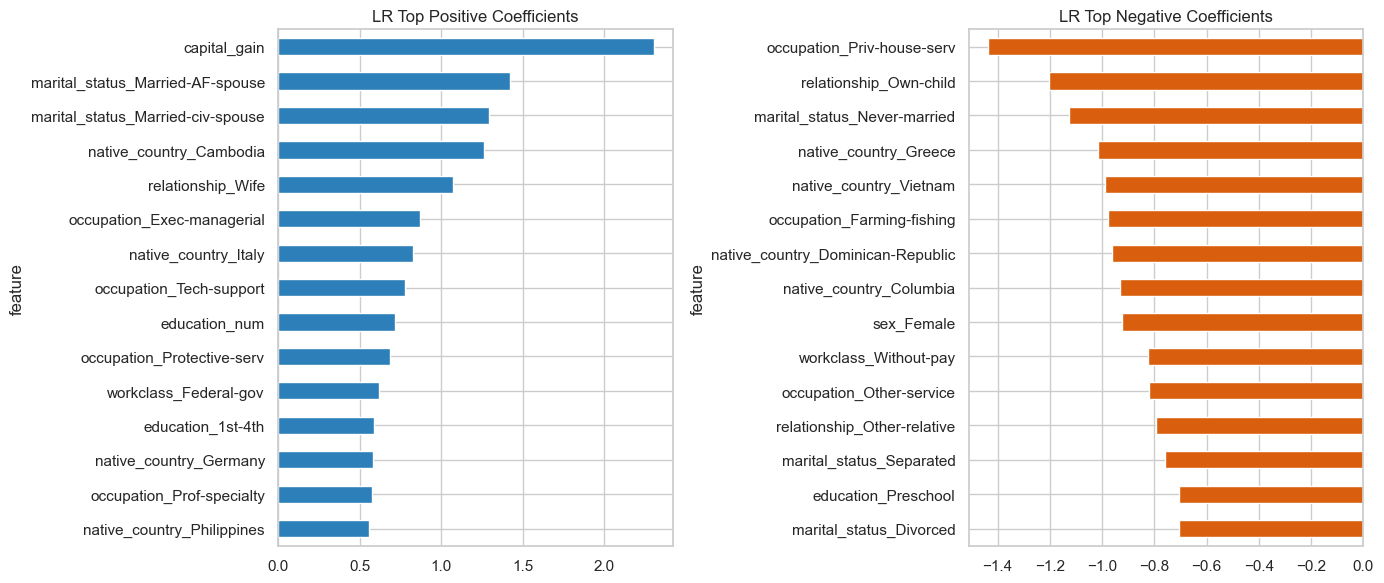

Saved LR coefficient figure to: figures\lr_top_coefs.png


<Figure size 800x600 with 0 Axes>

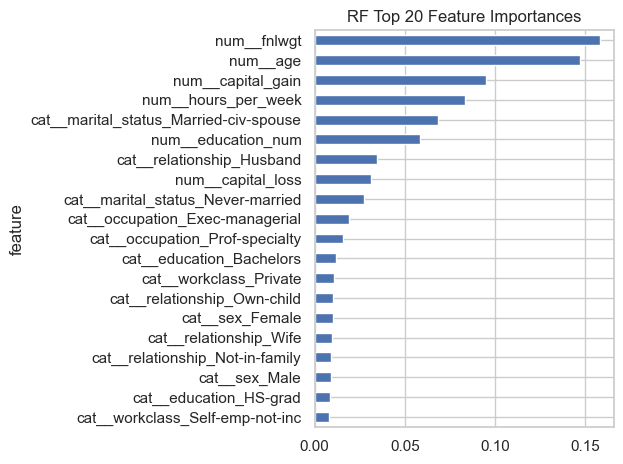

Saved RF importances figure to: figures\rf_top_importances.png

Top LR positives:
                          feature     coef
                     capital_gain 2.305068
 marital_status_Married-AF-spouse 1.422152
marital_status_Married-civ-spouse 1.295168
          native_country_Cambodia 1.260062
                relationship_Wife 1.069829
       occupation_Exec-managerial 0.867925
             native_country_Italy 0.830329
          occupation_Tech-support 0.780770
                    education_num 0.715213
       occupation_Protective-serv 0.687869

Top LR negatives:
                          feature      coef
       occupation_Priv-house-serv -1.438252
           relationship_Own-child -1.203171
     marital_status_Never-married -1.125612
            native_country_Greece -1.015944
           native_country_Vietnam -0.988945
       occupation_Farming-fishing -0.976372
native_country_Dominican-Republic -0.960326
          native_country_Columbia -0.932627
                       sex_Fem

In [20]:
# Extract LR coefficients and RF importances with feature names
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

# Helper to build feature names from the fitted ColumnTransformer
def get_feature_names_from_ct(ct, numeric_cols, cat_cols):
    names = []
    for name, transformer, cols in ct.transformers_:
        if name == 'num':
            try:
                names.extend(transformer.get_feature_names_out(numeric_cols))
            except Exception:
                names.extend(list(numeric_cols))
        elif name == 'cat':
            try:
                names.extend(transformer.get_feature_names_out(cat_cols))
            except Exception:
                # Fallback: build names manually
                ohe = transformer
                cat_feature_names = []
                for col, cats in zip(cat_cols, ohe.categories_):
                    cat_feature_names.extend([f"{col}_{c}" for c in cats])
                names.extend(cat_feature_names)
        else:
            # ignore dropped/remainder
            pass
    return np.array(names)

# 1) Logistic Regression coefficients
ct_lr = pipe_lr.named_steps['preprocessor']
clf_lr = pipe_lr.named_steps['classifier']
lr_names = get_feature_names_from_ct(ct_lr, numeric_cols, cat_cols)
lr_coefs = clf_lr.coef_.ravel()

# Top positive/negative signals
k = min(15, lr_coefs.size)
pos_idx = np.argsort(lr_coefs)[-k:][::-1]
neg_idx = np.argsort(lr_coefs)[:k]

pos_df = pd.DataFrame({'feature': lr_names[pos_idx], 'coef': lr_coefs[pos_idx]})
neg_df = pd.DataFrame({'feature': lr_names[neg_idx], 'coef': lr_coefs[neg_idx]})

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pos_df.iloc[:k].plot(kind='barh', x='feature', y='coef', ax=axes[0], color='#2c7fb8', legend=False)
axes[0].invert_yaxis()
axes[0].set_title('LR Top Positive Coefficients')
neg_df.iloc[:k].sort_values('coef').plot(kind='barh', x='feature', y='coef', ax=axes[1], color='#d95f0e', legend=False)
axes[1].invert_yaxis()
axes[1].set_title('LR Top Negative Coefficients')
plt.tight_layout()
path_lr = os.path.join('figures', 'lr_top_coefs.png')
plt.savefig(path_lr, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved LR coefficient figure to: {path_lr}")

# 2) Random Forest importances
ct_rf = pipe_rf.named_steps['preprocessor']
rf = pipe_rf.named_steps['classifier']
rf_names = ct_rf.get_feature_names_out()
rf_imps = rf.feature_importances_

imp_df = pd.DataFrame({'feature': rf_names, 'importance': rf_imps}).sort_values('importance', ascending=False).head(20)
plt.figure(figsize=(8, 6))
imp_df.sort_values('importance').plot(kind='barh', x='feature', y='importance', legend=False)
plt.title('RF Top 20 Feature Importances')
plt.tight_layout()
path_rf = os.path.join('figures', 'rf_top_importances.png')
plt.savefig(path_rf, dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved RF importances figure to: {path_rf}")

# Show top tables
print('\nTop LR positives:')
print(pos_df.head(10).to_string(index=False))
print('\nTop LR negatives:')
print(neg_df.head(10).to_string(index=False))
print('\nTop RF importances:')
print(imp_df.head(10).to_string(index=False))

### What has been learned from model interpretation

- Ranked LR coefficients (positives/negatives) and RF importances were generated and saved to `figures/lr_top_coefs.png` and `figures/rf_top_importances.png`.
- The LR plot highlights a small set of high-magnitude features that increase or decrease odds of `>50K`, while RF importances show a handful of variables with outsized influence among 107 engineered features.
- The printed tables in the previous cell list the top signals for both models; these will be referenced directly in the white paper figures/tables.

### Subgroup performance (sex and race)

I evaluate per-group metrics for `sex` and `race` on the test set using both models. This highlights any notable disparities and informs ethical considerations and recommendations.

In [22]:
# Subgroup metrics for LR and RF (sex and race)
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Recompute predictions to be self-contained
pred_lr = pipe_lr.predict(X_test)
pred_rf = pipe_rf.predict(X_test)

X_test_eval = X_test.copy()
X_test_eval['y_true'] = y_test
X_test_eval['pred_lr'] = pred_lr
X_test_eval['pred_rf'] = pred_rf

metrics = {
    'accuracy': accuracy_score,
    'precision': lambda y, p: precision_score(y, p, zero_division=0),
    'recall': recall_score,
    'f1': f1_score,
}

def group_report(df, group_col, pred_col):
    rows = []
    for g, dfg in df.groupby(group_col):
        y = dfg['y_true']
        p = dfg[pred_col]
        rows.append({
            group_col: g,
            **{m: f(y, p) for m, f in metrics.items()}
        })
    return pd.DataFrame(rows).sort_values(by='f1', ascending=False)

for grp in ['sex', 'race']:
    print(f"\n=== {grp.upper()} — Logistic Regression ===")
    print(group_report(X_test_eval, grp, 'pred_lr').to_string(index=False))
    print(f"\n=== {grp.upper()} — Random Forest ===")
    print(group_report(X_test_eval, grp, 'pred_rf').to_string(index=False))


=== SEX — Logistic Regression ===
   sex  accuracy  precision   recall       f1
  Male  0.816055   0.735294 0.620301 0.672920
Female  0.931723   0.766082 0.550420 0.640587

=== SEX — Random Forest ===
   sex  accuracy  precision   recall       f1
  Male  0.814679   0.723842 0.634586 0.676282
Female  0.931259   0.755682 0.558824 0.642512

=== RACE — Logistic Regression ===
              race  accuracy  precision   recall       f1
             White  0.848765   0.746206 0.616725 0.675315
Asian-Pac-Islander  0.821429   0.690476 0.568627 0.623656
             Black  0.908463   0.684211 0.527027 0.595420
             Other  0.931818   0.250000 1.000000 0.400000
Amer-Indian-Eskimo  0.895522   0.500000 0.285714 0.363636

=== RACE — Random Forest ===
              race  accuracy  precision   recall       f1
             White  0.845744   0.729184 0.628571 0.675150
             Black  0.918826   0.728814 0.581081 0.646617
Asian-Pac-Islander  0.831633   0.750000 0.529412 0.620690
Amer-Indian-Es

### What I learned from subgroup performance

- By sex: both models show higher F1 for males than females (≈0.67 vs ≈0.64), with RF slightly improving recall while keeping precision comparable.
- By race: RF improves F1 for the Black subgroup vs LR (≈0.65 vs ≈0.60). White remains highest-support with stable performance (~0.67 F1). Smaller subgroups (e.g., Other, Amer-Indian-Eskimo) show more variability.
- Takeaway: Model choice affects subgroup trade-offs; RF modestly boosts recall for some groups while preserving overall AUC/accuracy.

### Conclusion

- Prepared the Adult dataset, standardized columns, handled `?` as `Unknown`, and created `income_binary`.
- Baselines: Logistic Regression (Acc 0.854, F1 0.668, AUC 0.904) and Random Forest (Acc 0.853, F1 0.672, AUC 0.900) performed similarly; RF slightly improved recall.
- Figures saved: `figures/eda_overview.png`, `figures/roc_lr_rf.png`, `figures/confusion_lr_rf.png`, `figures/lr_top_coefs.png`, `figures/rf_top_importances.png`.
- Interpretation tables/plots identify influential features for both models; subgroup metrics highlight modest performance differences across sex and race with RF improving some groups’ recall.